# So sánh các model trong bài toán dự đoán metrics RAM, CPU
3 model được lựa chọn để so sánh là:
- Facebook Prophet &rarr; Đại diện cho các model dạng statistical (ARIMA/SARIMA, ETS ,Prophet, ...)
- N-HiTS &rarr; Đại diện cho các model deep learning (LSTM, TFT, N-HiTS, ...)
- Amazon Chronos &rarr; Đại diện cho các model LLM-based (Chronos, TimeGPT, ...)

## Data

Data thu thập từ bộ dữ liệu datacenter của Bitbrain - Một nhà cung cấp dịch vụ chuyên sâu vào cung cấp quản lý hosting và computing cho doanh nghiệp. Bộ dataset bao gồm thông của 1250 VMs, trong đó em chọn 1 VM để lấy phục vụ so sánh giữa các mô hình.
Dataset gốc: https://www.kaggle.com/datasets/gauravdhamane/gwa-bitbrains

Dataset bao gồm 3 column: Timestamp, CPU Usage(%), RAM Usage(%). Dataset đã được xử lý qua so với dữ liệu gốc.

In [17]:
import pandas as pd
import numpy as np
original_df = pd.read_csv("collected_metrics.csv")
original_df['Timestamp'] = pd.to_datetime(original_df['Timestamp'], unit='ms')

print(original_df.head())
print("="*50)
print(original_df.info())

            Timestamp  Memory Usage  CPU Usage
0 2026-04-20 17:00:00     42.282991  11.566667
1 2026-04-20 17:00:15     42.291728  13.033333
2 2026-04-20 17:00:30     42.086092  12.533333
3 2026-04-20 17:00:45     42.024457  11.700000
4 2026-04-20 17:01:00     42.196733  13.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31675 entries, 0 to 31674
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Timestamp     31675 non-null  datetime64[ns]
 1   Memory Usage  31675 non-null  float64       
 2   CPU Usage     31675 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 742.5 KB
None


In [ ]:
print(min(train_df["CPU Usage"]))
print(min(train_df["Memory Usage"]))

100.0
71.92769955


In [18]:
train_df = original_df.iloc[:-300]
test_df = original_df.iloc[-300:]

print(train_df)
print("="*50)
print(test_df)

                Timestamp  Memory Usage  CPU Usage
0     2026-04-20 17:00:00     42.282991  11.566667
1     2026-04-20 17:00:15     42.291728  13.033333
2     2026-04-20 17:00:30     42.086092  12.533333
3     2026-04-20 17:00:45     42.024457  11.700000
4     2026-04-20 17:01:00     42.196733  13.000000
...                   ...           ...        ...
31370 2026-04-26 03:42:30     60.191783  15.900000
31371 2026-04-26 03:42:45     60.053899  14.966667
31372 2026-04-26 03:43:00     60.014265  13.633333
31373 2026-04-26 03:43:15     60.211084  14.866667
31374 2026-04-26 03:43:30     60.210131  15.066667

[31375 rows x 3 columns]
                Timestamp  Memory Usage  CPU Usage
31375 2026-04-26 03:43:45     60.288684  14.466667
31376 2026-04-26 03:44:00     60.298612  13.666667
31377 2026-04-26 03:44:15     60.207907  15.800000
31378 2026-04-26 03:44:30     60.356832  15.433333
31379 2026-04-26 03:44:45     60.254372  15.600000
...                   ...           ...        ...
31670

## Facebook Prophet

In [19]:
from prophet import Prophet

In [20]:
prophet_cpu_train_df = pd.DataFrame({
    'ds': train_df['Timestamp'],
    'y': train_df['CPU Usage']
})

prophet_memory_train_df = pd.DataFrame({
    'ds': train_df['Timestamp'],
    'y': train_df['Memory Usage']
})

print("--- CPU Train DF ---")
print(prophet_cpu_train_df.head())
print("\n--- Memory Train DF ---")
print(prophet_memory_train_df.head())

--- CPU Train DF ---
                   ds          y
0 2026-04-20 17:00:00  11.566667
1 2026-04-20 17:00:15  13.033333
2 2026-04-20 17:00:30  12.533333
3 2026-04-20 17:00:45  11.700000
4 2026-04-20 17:01:00  13.000000

--- Memory Train DF ---
                   ds          y
0 2026-04-20 17:00:00  42.282991
1 2026-04-20 17:00:15  42.291728
2 2026-04-20 17:00:30  42.086092
3 2026-04-20 17:00:45  42.024457
4 2026-04-20 17:01:00  42.196733


In [21]:
prophet_model_cpu = Prophet()
prophet_model_cpu.fit(prophet_cpu_train_df)

prophet_model_memory = Prophet()
prophet_model_memory.fit(prophet_memory_train_df)

09:03:02 - cmdstanpy - INFO - Chain [1] start processing
09:03:12 - cmdstanpy - INFO - Chain [1] done processing
09:03:12 - cmdstanpy - INFO - Chain [1] start processing
09:03:33 - cmdstanpy - INFO - Chain [1] done processing


In [22]:
future_cpu = prophet_model_cpu.make_future_dataframe(periods=300, freq="15s")
forecast_cpu = prophet_model_cpu.predict(future_cpu)
forecast_cpu[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
31670,2026-04-26 04:57:30,15.638526,8.434038,22.513753
31671,2026-04-26 04:57:45,15.640833,8.798733,22.610411
31672,2026-04-26 04:58:00,15.643144,8.714904,22.583039
31673,2026-04-26 04:58:15,15.645457,8.461038,22.326039
31674,2026-04-26 04:58:30,15.647772,9.035579,22.069947


In [23]:
future_memory = prophet_model_memory.make_future_dataframe(periods=300, freq="15s")
forecast_memory = prophet_model_memory.predict(future_memory)
forecast_memory[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
31670,2026-04-26 04:57:30,60.864973,59.063672,62.729599
31671,2026-04-26 04:57:45,60.862851,59.057308,62.532014
31672,2026-04-26 04:58:00,60.860728,59.022655,62.706621
31673,2026-04-26 04:58:15,60.858603,59.158187,62.722797
31674,2026-04-26 04:58:30,60.856477,58.998427,62.561161


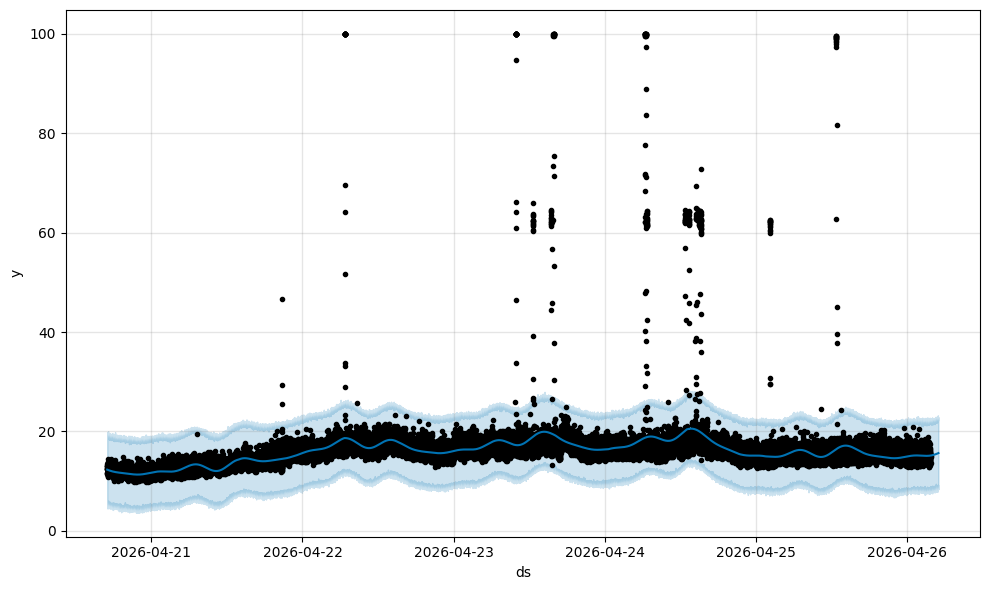

In [24]:
fig1 = prophet_model_cpu.plot(forecast_cpu)

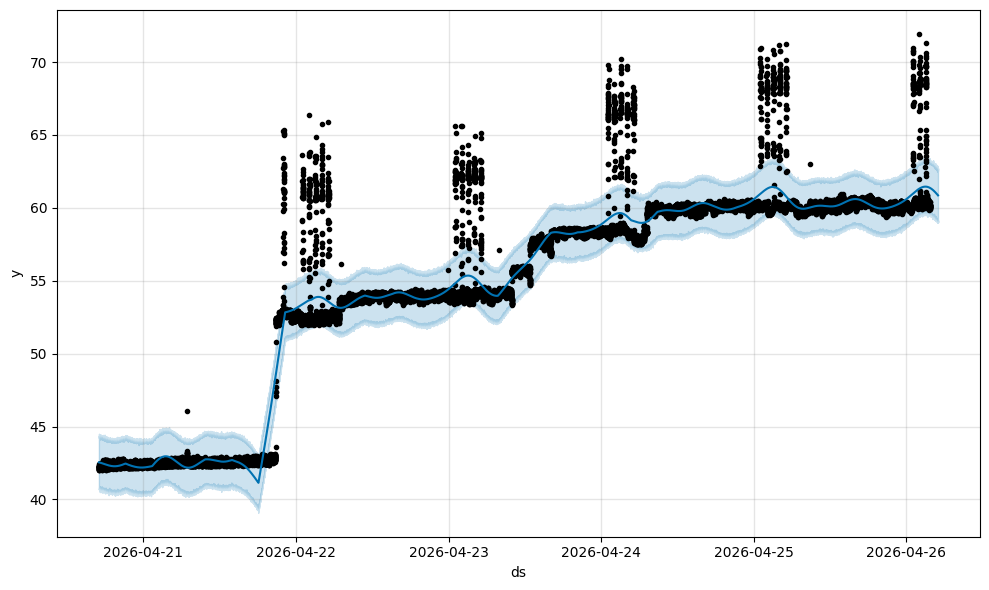

In [25]:
fig2 = prophet_model_memory.plot(forecast_memory)

## N-HiTS

In [27]:
import pandas as pd
import numpy as np
import lightning.pytorch as pl

from sklearn.preprocessing import StandardScaler
from pytorch_forecasting import TimeSeriesDataSet, NHiTS
from pytorch_forecasting.metrics import RMSE

import matplotlib.pyplot as plt

Chuẩn bị data

In [28]:
nhits_df = train_df.copy()

nhits_df["time_idx"] = np.arange(len(nhits_df))

# group
nhits_df["group"] = 0

# scale for each metric
scaler_cpu = StandardScaler()
scaler_mem = StandardScaler()

nhits_df["CPU Usage"] = scaler_cpu.fit_transform(nhits_df[["CPU Usage"]])
nhits_df["Memory Usage"] = scaler_mem.fit_transform(nhits_df[["Memory Usage"]])

In [29]:
max_encoder_length = 128
max_prediction_length = 300

training_cutoff = nhits_df["time_idx"].max() - max_prediction_length

In [30]:
cpu_train_ds = TimeSeriesDataSet(
    nhits_df[nhits_df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="CPU Usage",
    group_ids=["group"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_unknown_reals=["CPU Usage", "Memory Usage"],
)

cpu_val_ds = TimeSeriesDataSet.from_dataset(
    cpu_train_ds, nhits_df, predict=True, stop_randomization=True
)

In [31]:
mem_train_ds = TimeSeriesDataSet(
    nhits_df[nhits_df.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Memory Usage",
    group_ids=["group"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    time_varying_unknown_reals=["CPU Usage", "Memory Usage"],
)

mem_val_ds = TimeSeriesDataSet.from_dataset(
    mem_train_ds, nhits_df, predict=True, stop_randomization=True
)

In [32]:
cpu_train_loader = cpu_train_ds.to_dataloader(train=True, batch_size=64)
cpu_val_loader = cpu_val_ds.to_dataloader(train=False, batch_size=64)

mem_train_loader = mem_train_ds.to_dataloader(train=True, batch_size=64)
mem_val_loader = mem_val_ds.to_dataloader(train=False, batch_size=64)

In [33]:
cpu_model = NHiTS.from_dataset(
    cpu_train_ds,
    learning_rate=1e-3,
    hidden_size=128,
    dropout=0.1,
    loss=RMSE(),
)

mem_model = NHiTS.from_dataset(
    mem_train_ds,
    learning_rate=1e-3,
    hidden_size=128,
    dropout=0.1,
    loss=RMSE(),
)

/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [34]:
trainer = pl.Trainer(
    max_epochs=30,
    gradient_clip_val=0.1,
)

# train CPU
trainer.fit(cpu_model, cpu_train_loader, cpu_val_loader)

# train Memory
trainer.fit(mem_model, mem_train_loader, mem_val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type           | Params | Mode 
-----------------------------------------------------------
0 | loss            | RMSE           | 0      | train
1 | logging_metrics | ModuleList     | 0      | train
2 | embeddings      | MultiEmbedding | 0      | train
3 | model           | NHiTS          | 205 K  | train
-----------------------------------------------------------
205 K     Trainable params
0         Non-trainable params
205 K     Total params
0.822     Total estimated model params size (MB)
44        Modules in train mode
0         Modules in eval mode


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=2` in the `DataLoader` to improve performance.


/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=2` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 478/478 [00:32<00:00, 14.87it/s, v_num=3, train_loss_step=0.931, val_loss=0.212, train_loss_epoch=0.942]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 478/478 [00:32<00:00, 14.84it/s, v_num=3, train_loss_step=0.931, val_loss=0.212, train_loss_epoch=0.942]


/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /home/nguyentan/OpenstackDRS/app/predictor/lightning_logs/version_3/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type           | Params | Mode 
-----------------------------------------------------------
0 | loss            | RMSE           | 0      | train
1 | logging_metrics | ModuleList     | 0      | train
2 | embeddings      | MultiEmbedding | 0      | train
3 | model           | NHiTS          | 205 K  | train
-----------------------------------------------------------
205 K     Trainable params
0         Non-trainable params
205 K     Total params
0.822     Total estimated model params size (MB)
44        Modules in train mode
0         Modules in eval mode


`Trainer.fit` stopped: `max_epochs=30` reached.


In [35]:
cpu_preds = cpu_model.predict(cpu_val_loader)
mem_preds = mem_model.predict(mem_val_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/nguyentan/OpenstackDRS/venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=2` in the `DataLoader` to improve performance.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [36]:
cpu_preds = scaler_cpu.inverse_transform(cpu_preds.numpy())
mem_preds = scaler_mem.inverse_transform(mem_preds.numpy())

cpu_preds = cpu_preds[0]
mem_preds = mem_preds[0]

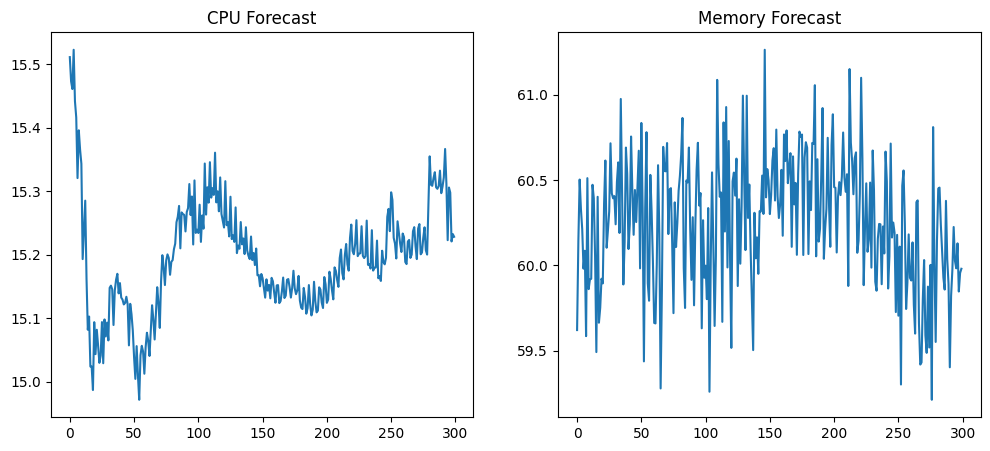

In [37]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(cpu_preds)
plt.title("CPU Forecast")

plt.subplot(1,2,2)
plt.plot(mem_preds)
plt.title("Memory Forecast")

plt.show()

## Amazon Chronos

In [38]:
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

predictor = TimeSeriesPredictor.load("AutogluonModels/ag-20260509_174426/")

print(predictor.model_names())
print(predictor.leaderboard())

['Chronos2ZeroShot', 'Chronos2FineTuned']
               model  score_val  pred_time_val  fit_time_marginal  fit_order
0  Chronos2FineTuned  -3.587635       2.748711        3244.907173          2
1   Chronos2ZeroShot  -3.627033       2.315556          11.585644          1


In [39]:
chronos_df = (
    train_df
    .melt(
        id_vars='Timestamp',
        value_vars=['CPU Usage', 'Memory Usage'],
        var_name='item_id',
        value_name='target'
    )
    .rename(columns={'Timestamp': 'timestamp'})
)

chronos_df['item_id'] = chronos_df['item_id'].map({
    'CPU Usage': 'CPU',
    'Memory Usage': 'Memory'
})

chronos_cpu_df = chronos_df.query("item_id == 'CPU'").reset_index(drop=True)
chronos_memory_df = chronos_df.query("item_id == 'Memory'").reset_index(drop=True)

cpu_train_data = TimeSeriesDataFrame.from_data_frame(
    chronos_cpu_df,
    id_column="item_id",
    timestamp_column="timestamp"
)

mem_train_data = TimeSeriesDataFrame.from_data_frame(
    chronos_memory_df,
    id_column="item_id",
    timestamp_column="timestamp"
)

In [63]:
finetuned_chronos_mem_pred = predictor.predict(mem_train_data[-600:], model="Chronos2FineTuned")
zeroshot_chronos_mem_pred = predictor.predict(mem_train_data[-600:], model="Chronos2ZeroShot")

finetuned_chronos_cpu_pred = predictor.predict(cpu_train_data[-600:], model="Chronos2FineTuned")
zeroshot_chronos_cpu_pred = predictor.predict(cpu_train_data[-600:], model="Chronos2ZeroShot")

## So sánh

### Đánh giá về accuracy
Metric lựa chọn: RMSE, MASE

In [64]:
# RMSE
def rmse(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

# MASE
def mase(y_train, y_true, y_pred, seasonality=24):
    y_train = np.array(y_train)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Naive forecast error (denominator)
    naive_forecast = np.abs(y_train[seasonality:] - y_train[:-seasonality])
    scale = np.mean(naive_forecast)
    
    # Model error (numerator)
    errors = np.abs(y_true - y_pred)
    
    return np.mean(errors) / scale

Đối với Memory

In [65]:
y_train_mem = train_df['Memory Usage']
y_true_mem = test_df['Memory Usage']
y_pred_prophet_mem = forecast_memory['yhat'].iloc[-300:]
y_pred_nhits_mem = mem_preds
y_pred_finetuned_chronos_mem = finetuned_chronos_mem_pred['mean']
y_pred_zeroshot_chronos_mem = zeroshot_chronos_mem_pred['mean']

In [66]:
eval_mem = pd.DataFrame({
    'Model': ['Prophet', 'N-HiTS', 'ZeroShot_Chronos', 'FineTuned_Chronos'],
    'RMSE': [
        rmse(y_true_mem, y_pred_prophet_mem),
        rmse(y_true_mem, y_pred_nhits_mem),
        rmse(y_true_mem, y_pred_zeroshot_chronos_mem),
        rmse(y_true_mem, y_pred_finetuned_chronos_mem)
    ],
    'MASE': [
        mase(y_train_mem, y_true_mem, y_pred_prophet_mem),
        mase(y_train_mem, y_true_mem, y_pred_nhits_mem),
        mase(y_train_mem, y_true_mem, y_pred_zeroshot_chronos_mem),
        mase(y_train_mem, y_true_mem, y_pred_finetuned_chronos_mem),
    ]
})

display(eval_mem)

,Model,RMSE,MASE
0,Prophet,2.416960,3.177098
1,N-HiTS,2.655692,2.564835
2,ZeroShot_Chronos,0.915059,0.734627
3,FineTuned_Chronos,0.913005,0.734473


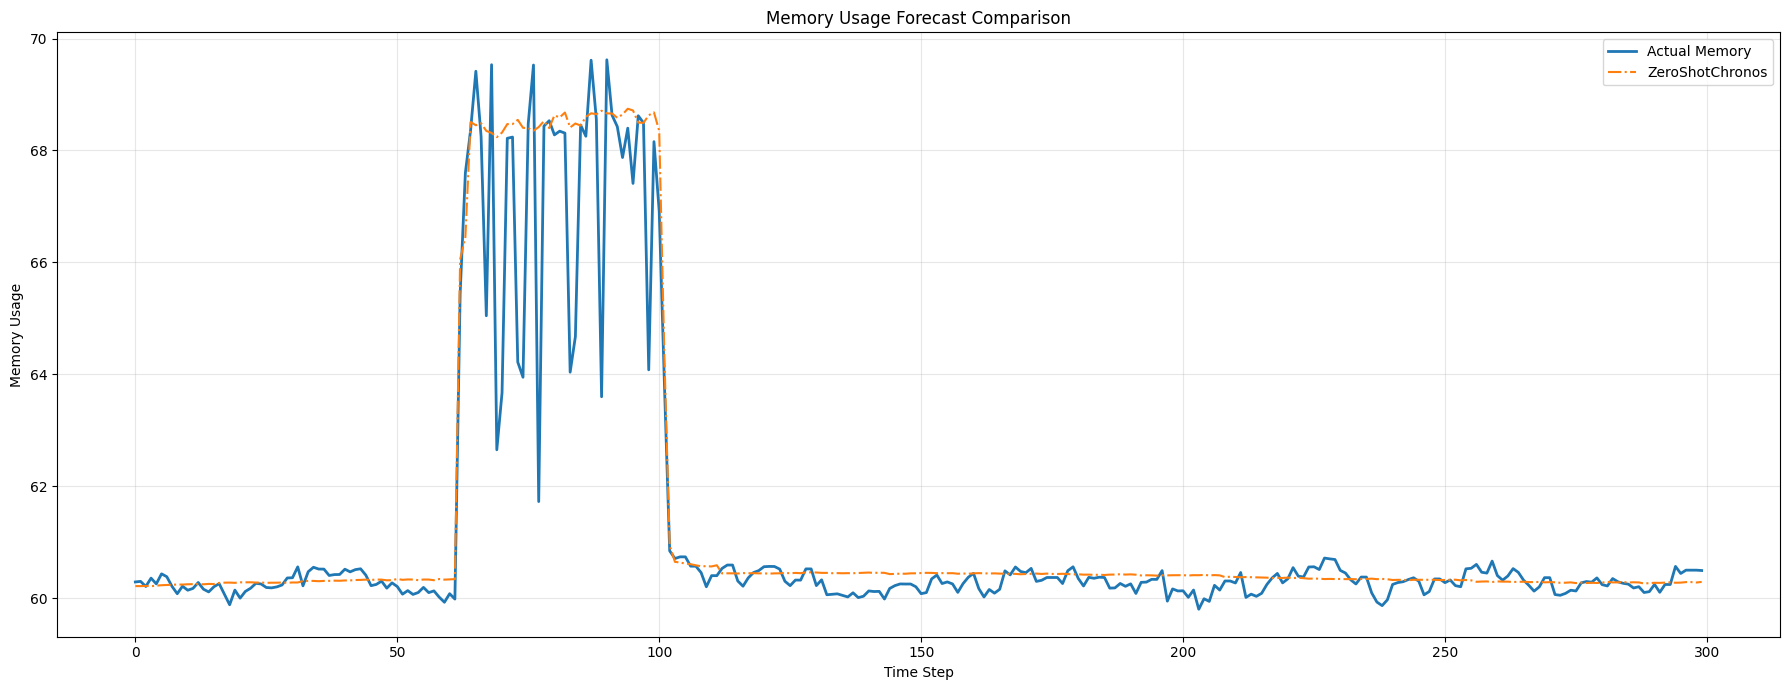

In [ ]:
import matplotlib.pyplot as plt

x = range(300)

# plot
plt.figure(figsize=(18,7))

plt.plot(x, y_true_mem, label='Actual Memory', linewidth=2)
plt.plot(x, y_pred_prophet_mem, label='Prophet', linestyle='--')
plt.plot(x, y_pred_nhits_mem, label='N-HiTS', linestyle=':')
plt.plot(x, y_pred_zeroshot_chronos_mem, label='ZeroShotChronos', linestyle='-.')
plt.plot(x, y_pred_finetuned_chronos_mem, label='FineTunedChronos', linestyle='-')

plt.title("Memory Usage Forecast Comparison")
plt.xlabel("Time Step")
plt.ylabel("Memory Usage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Đối với CPU

In [68]:
y_train_cpu = train_df['CPU Usage']
y_true_cpu = test_df['CPU Usage']
y_pred_prophet_cpu = forecast_cpu['yhat'].iloc[-300:]
y_pred_nhits_cpu = cpu_preds
y_pred_finetuned_chronos_cpu = finetuned_chronos_cpu_pred['mean']
y_pred_zeroshot_chronos_cpu = zeroshot_chronos_cpu_pred['mean']

In [69]:
eval_cpu = pd.DataFrame({
    'Model': ['Prophet', 'N-HiTS', 'ZeroShot_Chronos', 'FineTuned_Chronos'],
    'RMSE': [
        rmse(y_true_cpu, y_pred_prophet_cpu),
        rmse(y_true_cpu, y_pred_nhits_cpu),
        rmse(y_true_cpu, y_pred_zeroshot_chronos_cpu),
        rmse(y_true_cpu, y_pred_finetuned_chronos_cpu)
    ],
    'MASE': [
        mase(y_train_cpu, y_true_cpu, y_pred_prophet_cpu),
        mase(y_train_cpu, y_true_cpu, y_pred_nhits_cpu),
        mase(y_train_cpu, y_true_cpu, y_pred_zeroshot_chronos_cpu),
        mase(y_train_cpu, y_true_cpu, y_pred_finetuned_chronos_cpu),
    ]
})

display(eval_cpu)

,Model,RMSE,MASE
0,Prophet,1.326839,0.632892
1,N-HiTS,1.276183,0.590420
2,ZeroShot_Chronos,1.092927,0.463261
3,FineTuned_Chronos,1.091124,0.461230


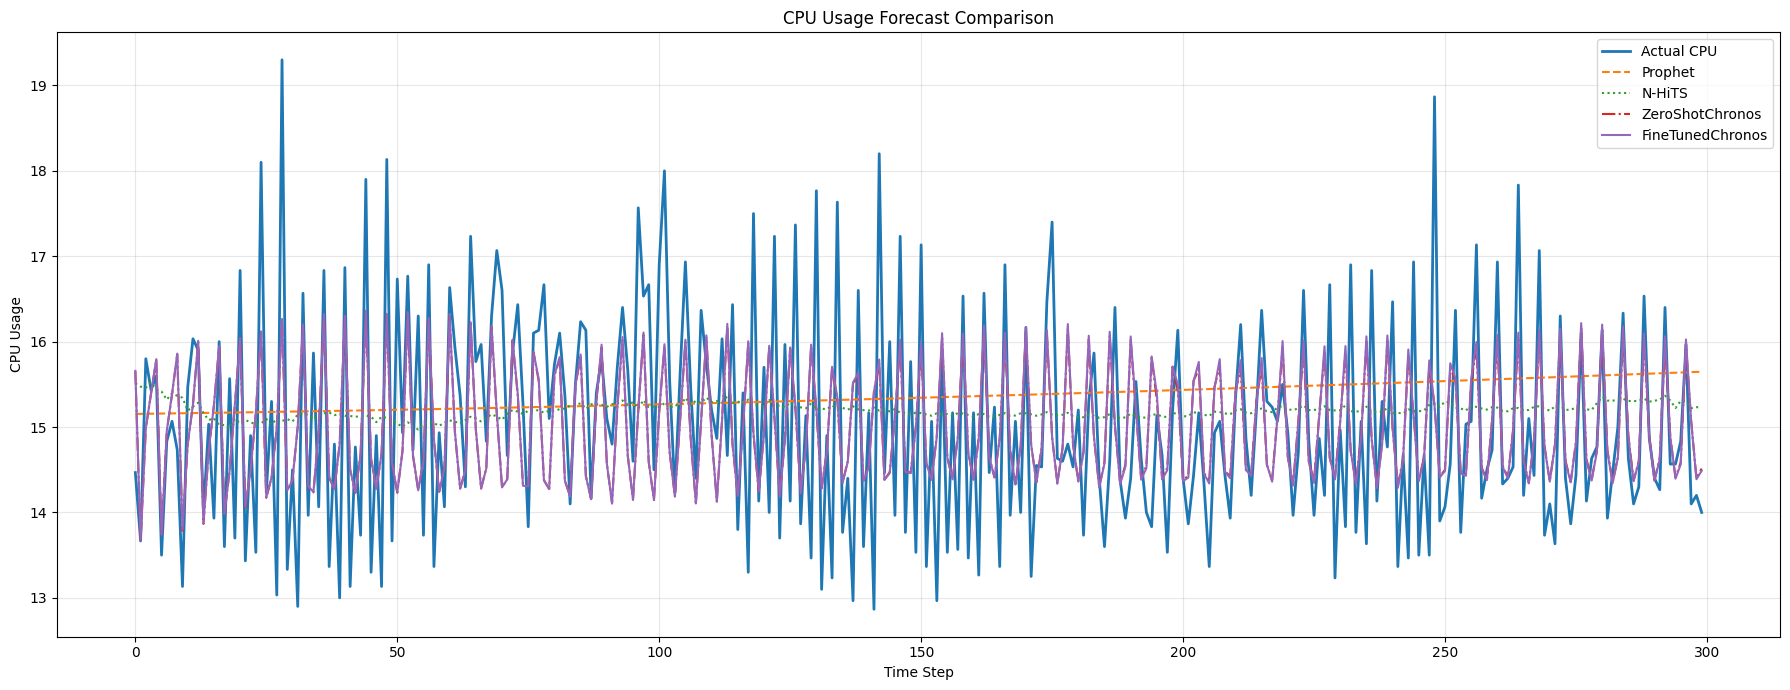

In [70]:
import matplotlib.pyplot as plt

x = range(300)

# plot
plt.figure(figsize=(18,7))

plt.plot(x, y_true_cpu, label='Actual CPU', linewidth=2)
plt.plot(x, y_pred_prophet_cpu, label='Prophet', linestyle='--')
plt.plot(x, y_pred_nhits_cpu, label='N-HiTS', linestyle=':')
plt.plot(x, y_pred_zeroshot_chronos_cpu, label='ZeroShotChronos', linestyle='-.')
plt.plot(x, y_pred_finetuned_chronos_cpu, label='FineTunedChronos', linestyle='-')

plt.title("CPU Usage Forecast Comparison")
plt.xlabel("Time Step")
plt.ylabel("CPU Usage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()